# Datensatz LLM - Detect AI Generated Text Dataset

---

**Erstellt von:** Hasan Hüseyin Demirci, Andreas Hubertus, Sebastian Rein, Vitalii Solonychnyi  

**Modul:** Grundlagen Data Science und Künstliche Intelligenz 2

**Dozentin:** Prof. Dr. Jennifer Schoch  

**Hochschule:** Duale Hochschule Baden-Württemberg Karlsruhe

**Datum:** 

---

# Inhaltsverzeichnis
machen wir am ende

# 1. Einleitung


#### 1.1 Motivation

In den letzten Jahren hat die rasante Entwicklung von Sprachmodellen und generativer Künstlicher Intelligenz zu einer zunehmenden Vermischung von KI-generierten und menschlich verfassten Texten geführt. Diese Entwicklung wirft zentrale Fragen hinsichtlich Authentizität, Transparenz und Verantwortung im digitalen Raum auf. Gerade in Bereichen wie Journalismus oder Social Media wird es immer wichtiger, die Herkunft von Texten zuverlässig zu erkennen, um Täuschung und Fehlinformationen zu vermeiden.

#### 1.2 Zielsetzung


Die Zentrale Forschungsfrage dieser Analyse lautet daher: 

*Wodurch unterscheiden sich KI-generierte von menschengeschriebenen Texten, und inwieweit lässt sich ein präzises Vorhersagemodell zur Unterscheidung beider entwickeln?*

Der Datensatz "AI Vs Human Text", der auf Kaggle zur Verfügung steht, ist hierfür die Grundlage. Er kann über folgenden Link aufgerufen, heruntergeladen und ausgelesen werden:

https://www.kaggle.com/datasets/shanegerami/ai-vs-human-text/data


Die Analyse läuft auf Grundlage des CRISP-DM Prozesses, einem standardisierten Vorgehensmodell für Data-Science-Projekte.

Zu Beginn des Projekts wurde eine SMART-Zielsetzung festgelegt.

Ziel des Projekts ist es, bis zum 28.04.2026 ein Klassifikationsmodell zu entwickeln, das zwischen menschlich verfassten und KI-generierten Texten unterscheiden kann und auf dem Testdatensatz eine Genauigkeit von mindestens 90 % erreicht.

S – Spezifisch: Entwicklung eines Modells zur Unterscheidung zwischen menschlichen und KI-generierten Texten.

M – Messbar: Bewertung der Modellleistung anhand der Genauigkeit (Accuracy) auf dem Testdatensatz.

A – Achievable: Das Ziel ist realistisch, da ein ausreichend großer und balancierter Datensatz für Training und Evaluation zur Verfügung steht.

R – Relevant: Die Aufgabe steht im direkten Zusammenhang mit der zentralen Fragestellung des Projekts.

T – Time-bound: Umsetzung des Ziels bis zum 28.04.2026.

Langfristig soll diese Arbeit dazu beitragen, Vertrauen in digitale Inhalte zu stärken und Werkzeuge zu entwickeln, die eine transparente Nutzung von KI im Schreibprozess ermöglichen.

#### 1.3 Forschungsstand


Es gibt bereits einige Publikationen zu diesem Thema, beispielweise das Paper "Spotting LLMs With Binoculars: Zero-Shot Detection of Machine-Generated Text". Hier wird festgestellt, das sich heutige Sprachmodelle, obwohl sie sehr gut sind, immer noch in ihren statistischen Signaturen signifikant vom Menschen unterscheiden. Menschen würden oft intuitiv und unregelmäßig schreiben, die KI bewege sich stattdessen in einem sehr vorhersehbaren, mathematisch wahrscheinlichen Korridor.
Bereits 2019 kamen die Autoren des Papers "GLTR: Statistical Detection and Visualization of Generated Text." zu einem ähnlichen Schluss. LLMs verwendeten fast ausschließlich Worte mit sehr hohen Wahrscheinlichkeiten. Die generierten Texte seien dadruch sehr glatt, während Menschen regelmäßig Wörter streuen würden, die außerhalb der statistischen Erwartung eines Sprachmodells lägen.
Ein weiteres Merkmal von LLMs sei, so das Paper "Automatic Detection of Machine Generated Text: A Critical Survey.", dass die Texte der KI zwar innerhalb eines Satzes logisch klängen, aber bei mehreren Sätzen oft der rote Faden verloren gehe und sich selbst wiedersprochen würde. Generierte Texte würden plausibel klingen, erfänden aber oft Fakten (="Haluzinieren"), da sie nur Worte vorhersagen, statt auf echtes Wissen zurückzugreifen.
Aus diesen Forschungserkenntnissen wird klar, dass LLMs zwar Texte auf hohem Niveau produzieren, die abber eindeutig Unterschiede zu menschengeschriebenen Texten aufweisen.

Auf Kaggle ist neben dem ausgewählten Datensatz auch Code einsehbar, in dem User den Datensatz direkt implementieren. Im Code von User Yamin H wird erkenntlich, dass eine Textbereinigung der Rohdaten bei diesem Datenbestand essentiell ist, damit ein Modell die feinen Unterschiede in der Wortwahl präzise analysieren kann. Weitere Programme zeigen, dass es durchaus möglich ist, Prediction-Modelle mit Accuracys höher als 90% zu schaffen.

---

# 2. Data Understanding


Für die folgende Analyse wird ein reduzierter und aufbereiteter Datensatz verwendet. Details zur Datensatzreduktion sowie zur weiteren Datenvorbereitung werden in Abschnitt 3 (Data Preparation) beschrieben.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("train.csv")

In [28]:
df.head()

,text,generated
0,Is important for young people to attend.\r\n\r...,1
1,As the world beys moved into a technological e...,0
2,"Dear, senator I hereby to inform you that I'm ...",0
3,"As a student Myself, I think students would be...",0
4,"Dear Principal,\r\n\r\nI understand your conc...",1


In [29]:
df.describe()

,generated
count,20000.000000
mean,0.500000
std,0.500013
min,0.000000
25%,0.000000
50%,0.500000
75%,1.000000
max,1.000000


In [30]:
print((df["generated"] == 1).sum())

10000


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       20000 non-null  object
 1   generated  20000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 312.6+ KB


Anzahl Wörter in AI-generierten Texten: 3498028
Anzahl Wörter in menschlich generierten Texten: 4242792


C:\Users\Andre\AppData\Local\Temp\ipykernel_25384\4286933994.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_ai['tokens'].apply(len), df_human['tokens'].apply(len)], labels=['AI-generierte Texte', 'menschlich generierte Texte'])


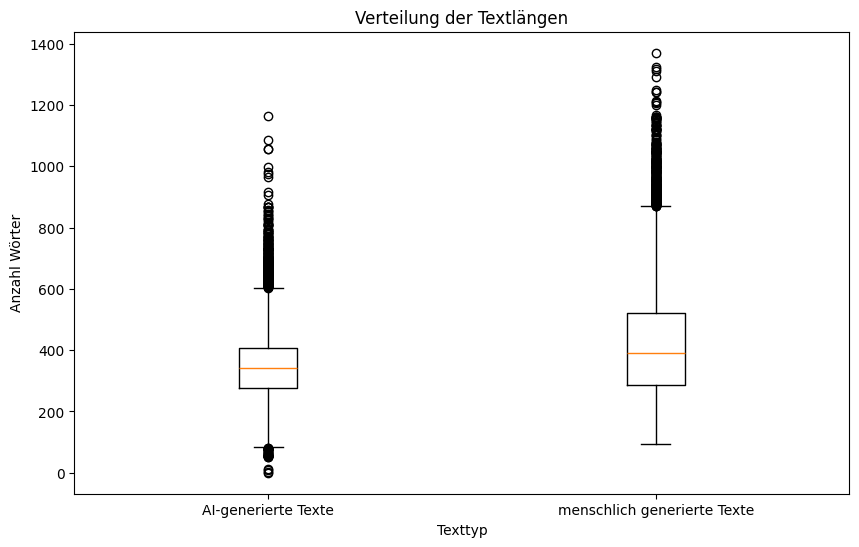

In [32]:
import re


df_human = df[df['generated'] == 0].copy()
df_ai = df[df['generated'] == 1].copy()

top_n = 20
df_ai['tokens'] = df_ai['text'].str.lower().apply(lambda x: re.findall(r'\b\w+\b', str(x)))
df_human['tokens'] = df_human['text'].str.lower().apply(lambda x: re.findall(r'\b\w+\b', str(x)))

word_list_ai = np.concatenate(df_ai["tokens"].values)
word_list_human = np.concatenate(df_human["tokens"].values)

print(f"Anzahl Wörter in AI-generierten Texten: {len(word_list_ai)}")
print(f"Anzahl Wörter in menschlich generierten Texten: {len(word_list_human)}")

plt.figure(figsize=(10, 6))
plt.boxplot([df_ai['tokens'].apply(len), df_human['tokens'].apply(len)], labels=['AI-generierte Texte', 'menschlich generierte Texte'])
plt.title("Verteilung der Textlängen")
plt.xlabel("Texttyp")
plt.ylabel("Anzahl Wörter")
plt.show()


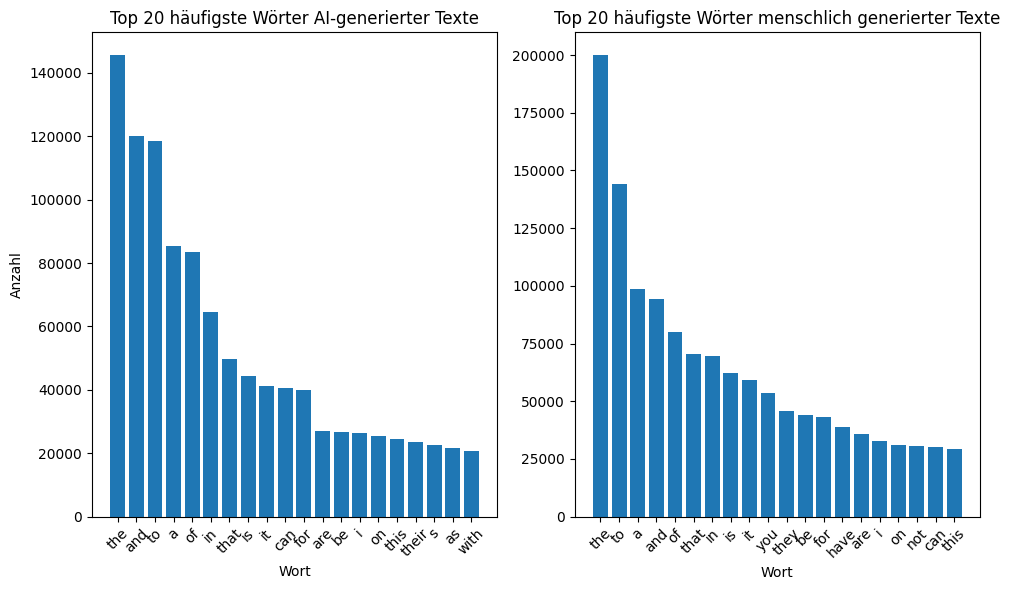

In [33]:


word_counts_ai = pd.Series(word_list_ai).value_counts()
word_counts_ai = word_counts_ai.reset_index()
word_counts_ai.columns = ["word", "count"]

word_counts_human = pd.Series(word_list_human).value_counts()
word_counts_human = word_counts_human.reset_index()
word_counts_human.columns = ["word", "count"]

top_words_ai = word_counts_ai.head(top_n)
top_words_human = word_counts_human.head(top_n)


plt.figure(figsize=(10, 6))
plt.subplot(1,2,1)
plt.bar(top_words_ai["word"], top_words_ai["count"])
plt.title(f"Top {top_n} häufigste Wörter AI-generierter Texte")
plt.xlabel("Wort")
plt.ylabel("Anzahl")
plt.xticks(rotation=45)

plt.subplot(1,2,2)
plt.bar(top_words_human["word"], top_words_human["count"])
plt.title(f"Top {top_n} häufigste Wörter menschlich generierter Texte")
plt.xlabel("Wort")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

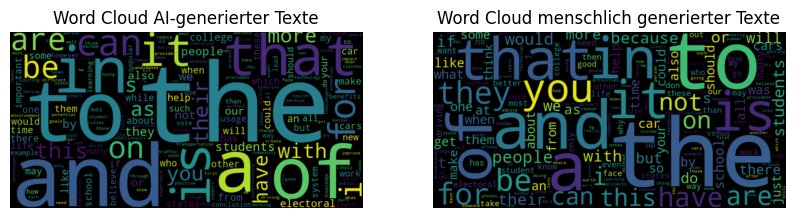

In [34]:
from wordcloud import WordCloud
wordcloud_ai = WordCloud(width=800, height=400).generate_from_frequencies(word_counts_ai.set_index("word")["count"])
wordcloud_human = WordCloud(width=800, height=400).generate_from_frequencies(word_counts_human.set_index("word")["count"])
plt.figure(figsize=(10, 6))
plt.subplot(1,2,1)
plt.imshow(wordcloud_ai, interpolation='bilinear')
plt.title("Word Cloud AI-generierter Texte")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(wordcloud_human, interpolation='bilinear')
plt.title("Word Cloud menschlich generierter Texte")
plt.axis('off')

plt.show()



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Andre\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


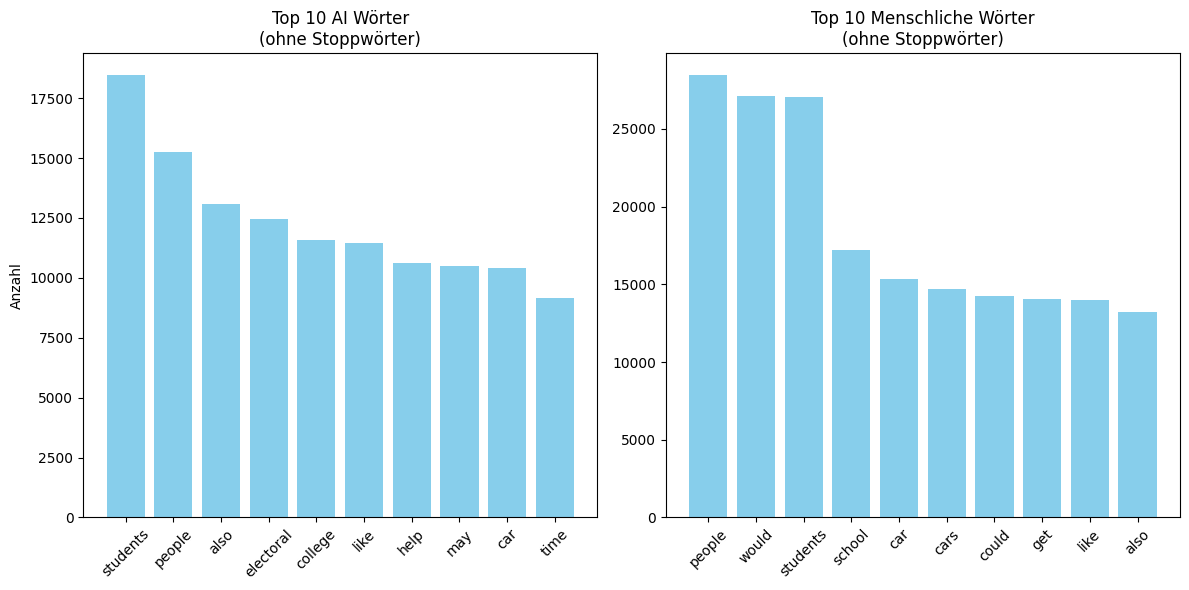

In [39]:
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

word_counts_ai_filtered = word_counts_ai[~word_counts_ai['word'].isin(stop_words)]
word_counts_human_filtered = word_counts_human[~word_counts_human['word'].isin(stop_words)]

top_n = 10 
top_words_ai_filtered = word_counts_ai_filtered.head(top_n)
top_words_human_filtered = word_counts_human_filtered.head(top_n)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(top_words_ai_filtered["word"], top_words_ai_filtered["count"], color='skyblue')
plt.title(f"Top {top_n} AI Wörter\n(ohne Stoppwörter)")
plt.xticks(rotation=45)
plt.ylabel("Anzahl")

plt.subplot(1, 2, 2)
plt.bar(top_words_human_filtered["word"], top_words_human_filtered["count"], color='skyblue')
plt.title(f"Top {top_n} Menschliche Wörter\n(ohne Stoppwörter)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Beispiel encoded:  ['count']


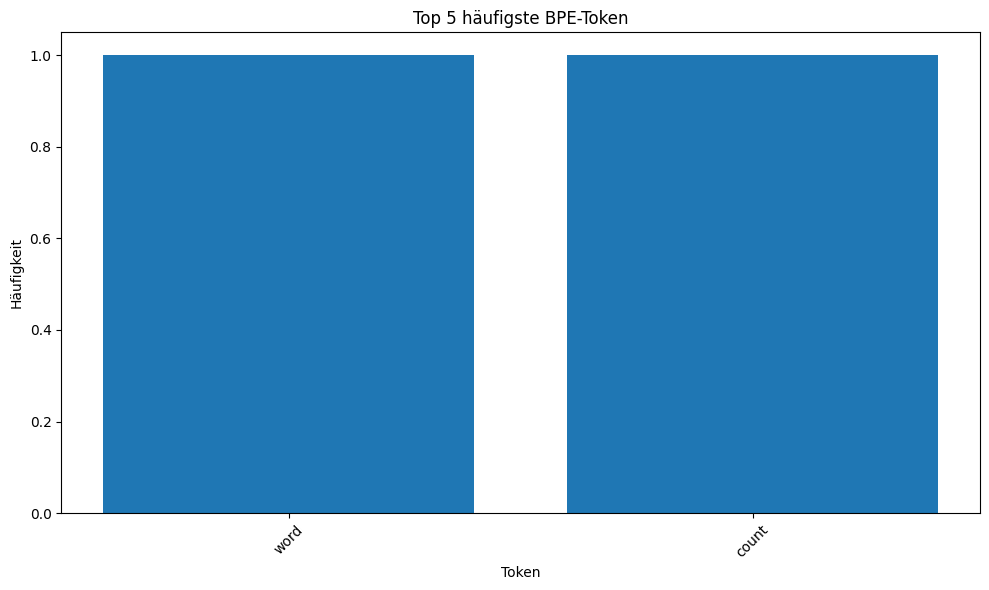

In [ ]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import BpeTrainer


tokenizer = Tokenizer(BPE())
tokenizer.pre_tokenizer = Whitespace() # zunächst Trennung durch Leerzeichen
trainer = BpeTrainer(vocab_size=30000) # k=3000


tokenlist = word_counts_ai[~word_counts_ai["word"].isin(stop_words)]

text_data = tokenlist.astype(str).tolist()
tokenizer.train_from_iterator(text_data, trainer)

all_tokens = []
for sentence in tokenlist: 
    encoded = tokenizer.encode(sentence) # Elemente des sentence werden Tokenisiert
    all_tokens.extend(encoded.tokens) # .extend() fügt Elemente an das Ende einer Liste an

print("Beispiel encoded: ", encoded.tokens)

# Häufigkeiten
token_series = pd.Series(all_tokens) # umwandeln der Liste als Pandas Series
token_freq = token_series.value_counts() # zählt Token
top_n = 5
top_tokens = token_freq.head(top_n)

# Barplot mit matplotlib
plt.figure(figsize=(10, 6))
plt.bar(top_tokens.index, top_tokens.values)
plt.title(f"Top {top_n} häufigste BPE-Token")
plt.xlabel("Token")
plt.ylabel("Häufigkeit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Data Preparation

## 3.1 Datensatzreduktion und Klassenbalancierung

Der ursprüngliche Datensatz umfasst 487.235 Texte. Für die vorliegende Analyse wurde daraus eine reduzierte Stichprobe erstellt, um den Rechenaufwand zu verringern und die Experimente im Rahmen des Projekts effizient durchführen zu können.

Für den Trainingsdatensatz wurden 20.000 Texte ausgewählt. Diese Größe wurde als ausreichend angesehen, um aussagekräftige Modelle zu trainieren und gleichzeitig eine praktikable Datenmenge für die Experimente zu behalten.

Dabei wurde auf eine ausgeglichene Klassenverteilung geachtet, sodass jeweils 10.000 menschlich verfasste und 10.000 KI-generierte Texte enthalten sind. Eine solche Klassenbalancierung verhindert, dass das Modell durch eine ungleiche Verteilung der Klassen verzerrt wird.

Zusätzlich wurde ein separater Testdatensatz mit 5.000 Texten erstellt, bestehend aus jeweils 2.500 Beispielen pro Klasse. Dieser Datensatz dient der Evaluation der Modelle auf zuvor ungesehenen Daten und ermöglicht eine objektive Bewertung der Modellleistung.

Die Trainings- und Testdatensätze wurden mithilfe eines separaten Skripts aus dem ursprünglichen Datensatz erstellt. Der folgende Code veranschaulicht den Prozess der Datensatzaufbereitung.

```python
df = pd.read_csv("AI_Human.csv")

human = df[df["generated"] == 0]
ai = df[df["generated"] == 1]

train_human = human.sample(10000, random_state=42)
train_ai = ai.sample(10000, random_state=42)

train = pd.concat([train_human, train_ai]).sample(frac=1, random_state=42)

remaining_human = human.drop(train_human.index)
remaining_ai = ai.drop(train_ai.index)

test_human = remaining_human.sample(2500, random_state=42)
test_ai = remaining_ai.sample(2500, random_state=42)

test = pd.concat([test_human, test_ai]).sample(frac=1, random_state=42)

train.to_csv("train_data.csv", index=False)
test.to_csv("test_data.csv", index=False)

## 3.2 Laden und Überprüfung der Datensätze

In [37]:
# Laden der vorbereiteten Datensätze
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# Klassenverteilung überprüfen
print("\nKlassenverteilung (Train):")
print(train["generated"].value_counts())

print("\nKlassenverteilung (Test):")
print(test["generated"].value_counts())



Klassenverteilung (Train):
generated
1    10000
0    10000
Name: count, dtype: int64

Klassenverteilung (Test):
generated
0    2500
1    2500
Name: count, dtype: int64


Die Überprüfung zeigt, dass beide Datensätze die erwartete Größe sowie eine ausgeglichene Klassenverteilung aufweisen. Damit sind die Daten für die anschließende Modellierung geeignet.

## 4. Machine Learning

Der Datensatz besteht aus einer Input- und einer Outputvariable:
Die Input-Variable ist ein String mit einem Text, die Output-Variable ist die Einschätzung, ob der Text von einem Menschen oder einer KI geschrieben wurde. Dies wird in Form einer Zahl ausgedrückt, mit 0 für menschengeschrieben und 1 für KI-verfasst.
Da die Zielvariable nur diskrete Klassen annimmt ist, handelt es sich eindeutig um eine Klassifikationsaufgabe.
Eine gute Predictionfrage wäre daher: 
*Wie hoch ist die Wahrscheinlichkeit, dass ein gegebener Text von einer KI und nicht von einem Menschen geschrieben wurde?*

Eine Frage zur Inference ist:
*Welche Texteigenschaften (z.B. Satzlänge, Wortvielfalt, Perplexity) stehen statistisch in Zusammenhang damit, ob ein Text von einer KI oder von einem Menschen verfasst wurde?*



In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Daten laden
# Ersetze 'deine_datei.csv' durch deinen Dateipfad
df = pd.read_csv('train.csv')

# 2. X (Merkmale) und y (Zielvariable) trennen
# Ersetze 'ziel_spalte' durch den Namen deiner Ergebnis-Spalte
X = df.drop('generated', axis=1) 
y = df['generated']

# 3. Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. SKALIERUNG (Extrem wichtig für KNN!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Modell trainieren
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# 6. Vorhersage und Auswertung
y_pred = knn.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

ValueError: could not convert string to float: 'The culture of Generic_City, France is incredibly diverse and vibrant. From the famous soccer team, Wait German, to the wide range of cuisines and activities available to locals, there is something to appeal to everyone. Traditional French cuisine, such as escargot, Pate, and ratatouille can be found in the many restaurants and cafés, alongside popular Asian and American fare. On the weekends, visitors and locals alike can explore the nearby beaches, enjoy a bike ride through the city, or visit the many attractions and monuments found throughout Generic_City.\r\n\r\nWhile religious diversity is present throughout French society, there are three predominant religions in Generic_City: Christianity, Judaism, and Islam. Each religious group celebrates its own set of holidays, such as Easter, Passover, and Ramadan, which are usually marked with community celebrations or religious services.\r\n\r\nFinally, the people of Generic_City are general

### TODO 

- SMART-Ziel überprüfen (1.2 Zielsetzung, Team)
- Erklärung zur Regex-basierten Vorverarbeitung hinzufügen (2. Data Understanding, Andreas)

# Literaturverzeichnis

[1] Gehrmann et al. (2019). *GLTR: Statistical Detection and Visualization of Generated Text.*  
https://arxiv.org/abs/1906.04043

[2] Hans et al. (2024). *Spotting LLMs With Binoculars: Zero-Shot Detection of Machine-Generated Text.*  
https://arxiv.org/abs/2401.12070

[3] Jawahar et al. (2020). *Automatic Detection of Machine Generated Text: A Critical Survey.*  
https://arxiv.org/abs/2001.01314

[4] Yamin H (2024). *AI Text Cleaning & Preprocessing Guide. Kaggle Notebook.*
https://www.kaggle.com/code/yaminh/ai-text-cleaning
